In [ ]:
!pip install xgboost optuna shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.4 MB/s eta 0:00:00


In [30]:
# SECTION 1 ▸ Imports & Global Configuration
# ──────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")          # Keep notebook output clean

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import optuna
import xgboost as xgb

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.compose          import ColumnTransformer
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

In [31]:
# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Aesthetic Defaults ───────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"      : 150,
    "axes.spines.top" : False,
    "axes.spines.right": False,
    "font.family"     : "DejaVu Sans",
})
PALETTE = {"baseline": "#4C9BE8", "optimized": "#E8724C"}   # blue / orange

# ── Silence Optuna's per-trial verbosity (show only the final summary) ───────
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=" * 70)
print("  HEART DISEASE CLASSIFICATION — XGBoost + Optuna Pipeline")
print("=" * 70)

  HEART DISEASE CLASSIFICATION — XGBoost + Optuna Pipeline


In [32]:
# ──────────────────────────────────────────────────────────────────────────────
# SECTION 2 ▸ Data Loading & Quick EDA
# ──────────────────────────────────────────────────────────────────────────────
DATA_PATH = "dataset/heart_cleveland_upload.csv"

print("\n[1/7]  Loading dataset …")
df = pd.read_csv(DATA_PATH)

print(f"       Shape        : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"       Missing values: {df.isnull().sum().sum()}")
print(f"       Target balance (condition):")
print(df["condition"].value_counts().rename({0: "No Disease", 1: "Disease"}))

# ── Feature Taxonomy ─────────────────────────────────────────────────────────
# Categorical features that should be One-Hot Encoded.
# Although some are already numerically encoded (e.g. cp = 0-3), they are
# *nominal* or *ordinal* and should not be treated as continuous values.
CATEGORICAL_FEATURES = ["cp", "restecg", "slope", "thal"]

# Continuous / count features that benefit from standardisation.
NUMERICAL_FEATURES   = ["age", "trestbps", "chol", "thalach",
                         "oldpeak", "ca", "fbs", "exang", "sex"]

TARGET = "condition"

X = df.drop(columns=[TARGET])
y = df[TARGET]




[1/7]  Loading dataset …
       Shape        : 297 rows × 14 columns
       Missing values: 0
       Target balance (condition):
condition
No Disease    160
Disease       137
Name: count, dtype: int64


In [33]:
# ──────────────────────────────────────────────────────────────────────────────
# SECTION 3 ▸ Preprocessing — 80 / 20 Stratified Split + ColumnTransformer
# ──────────────────────────────────────────────────────────────────────────────
print("\n[2/7]  Splitting data (80 / 20 stratified) and building preprocessor …")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y          # Preserves class ratio in both splits
)

print(f"       Train set : {X_train.shape[0]} samples")
print(f"       Test  set : {X_test.shape[0]}  samples")

# ── Column Transformer ───────────────────────────────────────────────────────
# One-Hot Encode nominal/ordinal categoricals; drop the first level to avoid
# the dummy-variable trap (multicollinearity).
# StandardScaler centres & normalises continuous features — XGBoost is not
# sensitive to scale, but it keeps SHAP values on a comparable magnitude.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),                                  NUMERICAL_FEATURES),
        ("cat", OneHotEncoder(drop="first", sparse_output=False),  CATEGORICAL_FEATURES),
    ],
    remainder="drop"
)

# Fit on training data only — never leak test statistics
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# ── Recover interpretable feature names (needed for SHAP axis labels) ────────
num_names = NUMERICAL_FEATURES
cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
FEATURE_NAMES = num_names + cat_names
print(f"       Total features after encoding: {len(FEATURE_NAMES)}")



[2/7]  Splitting data (80 / 20 stratified) and building preprocessor …
       Train set : 237 samples
       Test  set : 60  samples
       Total features after encoding: 18


In [34]:
# ──────────────────────────────────────────────────────────────────────────────
# SECTION 4 ▸ Model 1 — XGBoost Baseline (Default Hyperparameters)
# ──────────────────────────────────────────────────────────────────────────────
print("\n[3/7]  Training Model 1 — XGBoost Baseline (default params) …")

baseline_model = xgb.XGBClassifier(
    objective    = "binary:logistic",
    eval_metric  = "logloss",
    random_state = RANDOM_STATE,
    # All other hyperparameters remain at XGBoost defaults
)
baseline_model.fit(X_train_proc, y_train)

y_pred_base  = baseline_model.predict(X_test_proc)
y_prob_baseline  = baseline_model.predict_proba(X_test_proc)[:, 1]

print("       ✓ Baseline model trained.")



[3/7]  Training Model 1 — XGBoost Baseline (default params) …
       ✓ Baseline model trained.


In [35]:
# ──────────────────────────────────────────────────────────────────────────────
# SECTION 5 ▸ Model 2 — Optuna-Optimized XGBoost
# ──────────────────────────────────────────────────────────────────────────────
print("\n[4/7]  Running Optuna hyperparameter search …")

# ── Why StratifiedKFold inside Optuna?  ──────────────────────────────────────
# A single train/validation split during HPO can overfit to that particular
# partition.  Using StratifiedKFold gives a robust generalisation estimate
# while preserving the class ratio in each fold.
N_OPTUNA_TRIALS = 80    # ↑ trials → better search, ↓ trials → faster runtime
CV_FOLDS        = 5

def objective(trial: optuna.Trial) -> float:
    """
    Optuna objective: maximise mean AUC-ROC across 5 stratified folds.
    We optimise AUC-ROC rather than accuracy because it better reflects
    the model's ability to *rank* diseased vs. healthy patients — critical
    in medical screening.
    """
    params = {
        "objective"        : "binary:logistic",
        "eval_metric"      : "logloss",
        "random_state"     : RANDOM_STATE,
        # Search space — each range is anchored to domain knowledge and
        # common XGBoost tuning practice
        "n_estimators"     : trial.suggest_int  ("n_estimators",   50, 500),
        "max_depth"        : trial.suggest_int  ("max_depth",       3,  10),
        "learning_rate"    : trial.suggest_float("learning_rate",  0.01, 0.3,  log=True),
        "subsample"        : trial.suggest_float("subsample",       0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree",0.5, 1.0),
        "min_child_weight" : trial.suggest_int  ("min_child_weight",1,   10),
        "gamma"            : trial.suggest_float("gamma",           0,   5),
        "reg_alpha"        : trial.suggest_float("reg_alpha",       0,   1),
        "reg_lambda"       : trial.suggest_float("reg_lambda",      0.5, 5),
    }

    model = xgb.XGBClassifier(**params)
    skf   = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    cv_scores = cross_val_score(
        model, X_train_proc, y_train,
        cv      = skf,
        scoring = "roc_auc",
        n_jobs  = -1
    )
    return cv_scores.mean()




[4/7]  Running Optuna hyperparameter search …


In [36]:
# ── Run the Optuna study ─────────────────────────────────────────────────────
study = optuna.create_study(
    direction  = "maximize",            # We want the highest AUC-ROC
    study_name = "xgboost_heart_hpo",
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_params
best_params.update({
    "objective"   : "binary:logistic",
    "eval_metric" : "logloss",
    "random_state": RANDOM_STATE,
})

print(f"\n       ✓ Best CV AUC-ROC : {study.best_value:.4f}")
print(f"       Best Params     : {best_params}")

# ── Train the optimised model on the full training set ───────────────────────
print("\n[5/7]  Training final optimised model on full training set …")
optimized_model = xgb.XGBClassifier(**best_params)
optimized_model.fit(X_train_proc, y_train)

y_pred_optimized = optimized_model.predict(X_test_proc)
y_prob_optimized = optimized_model.predict_proba(X_test_proc)[:, 1]

print("       ✓ Optimised model trained.")


  0%|          | 0/80 [00:00<?, ?it/s]


       ✓ Best CV AUC-ROC : 0.8879
       Best Params     : {'n_estimators': 218, 'max_depth': 7, 'learning_rate': 0.016401313858166015, 'subsample': 0.5264399228749757, 'colsample_bytree': 0.5206193672596946, 'min_child_weight': 6, 'gamma': 2.635501977458582, 'reg_alpha': 0.785899095825006, 'reg_lambda': 1.32400352886339, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42}

[5/7]  Training final optimised model on full training set …
       ✓ Optimised model trained.


In [37]:
# ──────────────────────────────────────────────────────────────────────────────
# SECTION 6 ▸ Evaluation
# ──────────────────────────────────────────────────────────────────────────────
print("\n[6/7]  Evaluating models …")

def compute_metrics(y_true, y_pred, y_prob, label: str) -> dict:
    """
    Compute all evaluation metrics for a single model.
    Recall is flagged as CRITICAL in medical contexts: a false negative
    (missed disease) is far more costly than a false positive.
    """
    return {
        "Model"    : label,
        "Accuracy" : round(accuracy_score (y_true, y_pred),            4),
        "Recall*"  : round(recall_score   (y_true, y_pred),            4),   # ★ Critical
        "Precision": round(precision_score(y_true, y_pred),            4),
        "F1-Score" : round(f1_score       (y_true, y_pred),            4),
        "AUC-ROC"  : round(roc_auc_score  (y_true, y_prob),            4),
    }

metrics_baseline  = compute_metrics(y_test, y_pred_baseline,  y_prob_baseline,  "XGBoost Baseline")
metrics_optimized = compute_metrics(y_test, y_pred_optimized, y_prob_optimized, "XGBoost Optimized")

results_df = pd.DataFrame([metrics_baseline, metrics_optimized]).set_index("Model")

print("\n" + "=" * 60)
print("  MODEL COMPARISON TABLE")
print("  (* Recall is the most critical metric for medical screening)")
print("=" * 60)
print(results_df.to_string())
print("=" * 60)



[6/7]  Evaluating models …

  MODEL COMPARISON TABLE
  (* Recall is the most critical metric for medical screening)
                   Accuracy  Recall*  Precision  F1-Score  AUC-ROC
Model                                                             
XGBoost Baseline     0.8833   0.8571     0.8889    0.8727   0.9431
XGBoost Optimized    0.8167   0.7143     0.8696    0.7843   0.9208


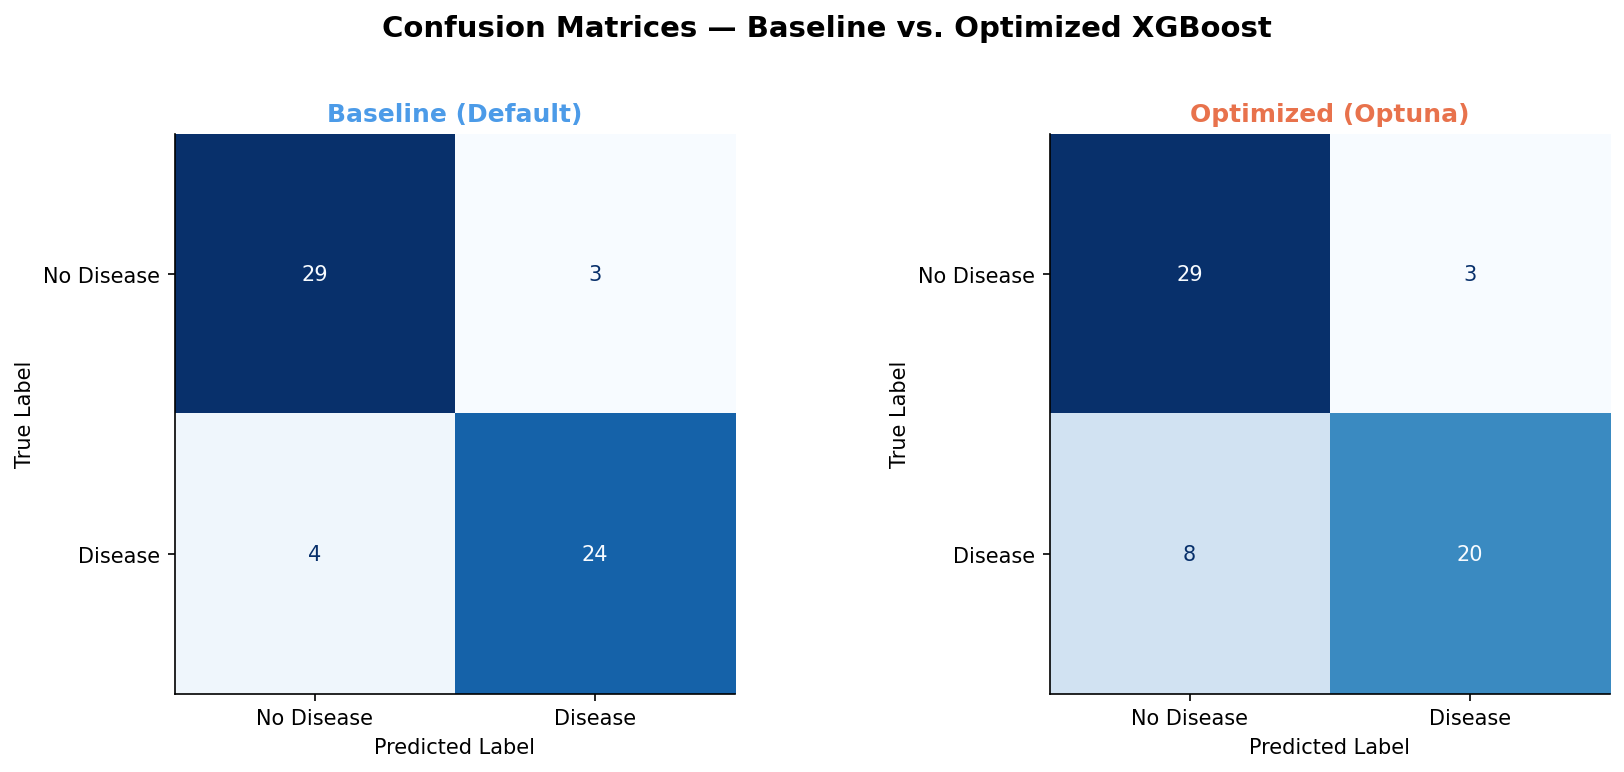

       ✓ Confusion matrices saved → confusion_matrices.png


In [12]:
# ── 6a. Side-by-Side Confusion Matrices ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices — Baseline vs. Optimized XGBoost",
             fontsize=14, fontweight="bold", y=1.02)

for ax, y_pred, title, color in zip(
        axes,
        [y_pred_baseline,  y_pred_optimized],
        ["Baseline (Default)", "Optimized (Optuna)"],
        [PALETTE["baseline"], PALETTE["optimized"]],
):
    cm  = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=12, fontweight="bold", color=color)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label",      fontsize=10)

plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches="tight")
plt.show()
print("       ✓ Confusion matrices saved → confusion_matrices.png")


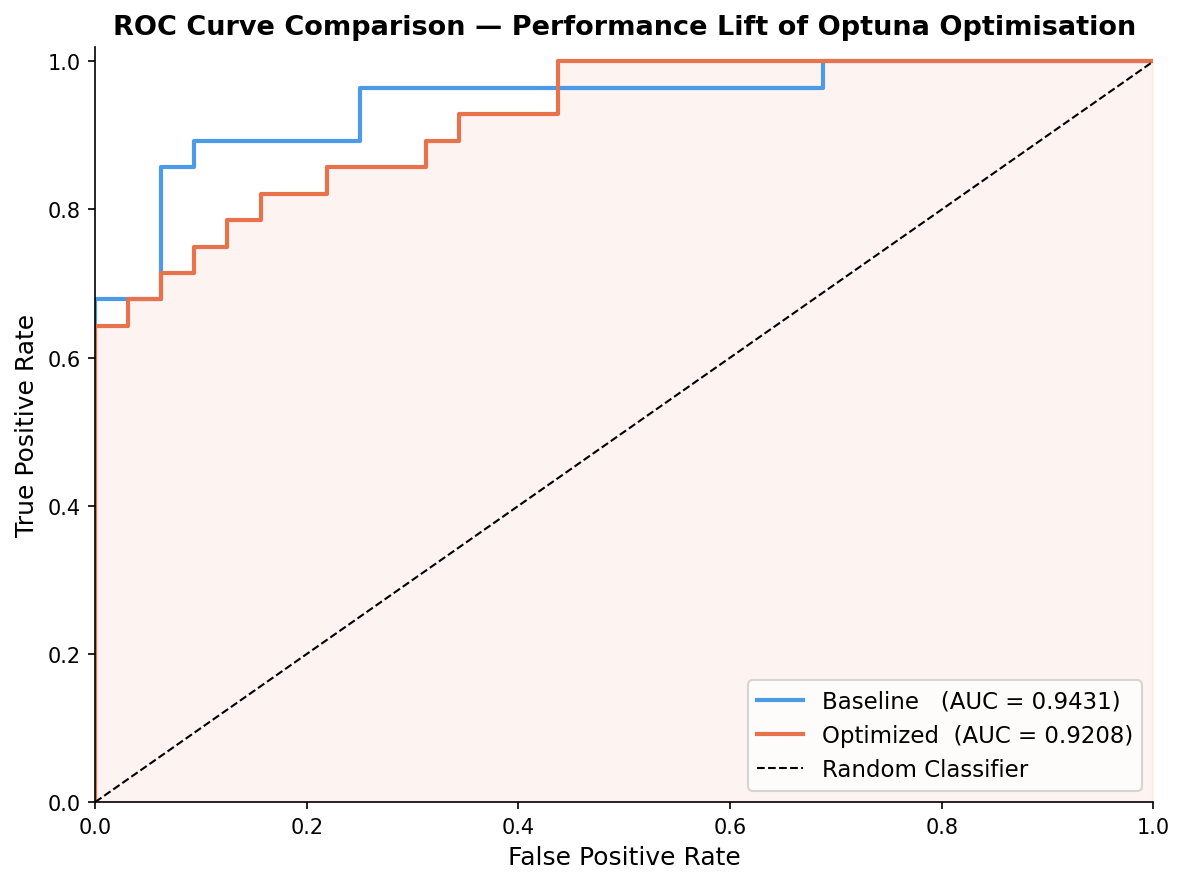

       ✓ ROC curves saved → roc_curves.png


In [13]:

# ── 6b. ROC Curves (both models on one chart) ────────────────────────────────
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_baseline)
fpr_o, tpr_o, _ = roc_curve(y_test, y_prob_optimized)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_b, tpr_b, color=PALETTE["baseline"],
        lw=2, label=f"Baseline   (AUC = {metrics_baseline['AUC-ROC']:.4f})")
ax.plot(fpr_o, tpr_o, color=PALETTE["optimized"],
        lw=2, label=f"Optimized  (AUC = {metrics_optimized['AUC-ROC']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")

ax.fill_between(fpr_o, tpr_o, alpha=0.08, color=PALETTE["optimized"])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate",  fontsize=12)
ax.set_title("ROC Curve Comparison — Performance Lift of Optuna Optimisation",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("roc_curves.png", bbox_inches="tight")
plt.show()
print("       ✓ ROC curves saved → roc_curves.png")




[7/7]  Computing SHAP values for the optimised model …


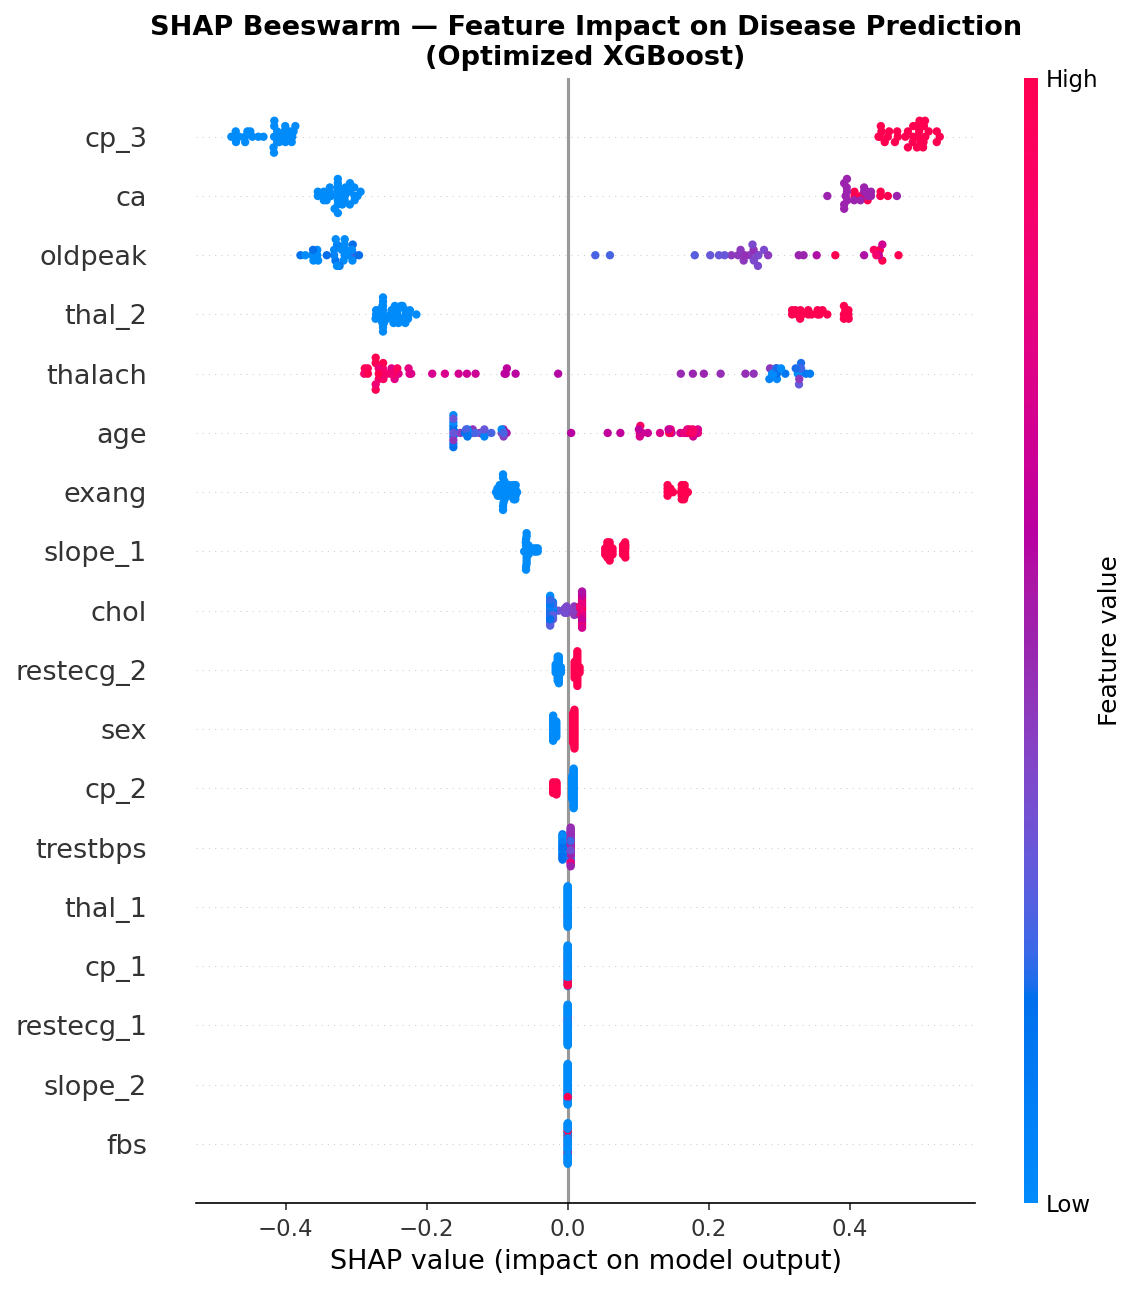

       ✓ SHAP beeswarm plot saved → shap_beeswarm.png


In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# SECTION 7 ▸ Explainability — SHAP Values + XGBoost Feature Importance
# ──────────────────────────────────────────────────────────────────────────────
print("\n[7/7]  Computing SHAP values for the optimised model …")

# ── SHAP TreeExplainer is native to tree-based models (no approximation) ─────
explainer = shap.TreeExplainer(optimized_model)
shap_values = explainer.shap_values(X_test_proc)     # shape: (n_samples, n_features)

X_test_df = pd.DataFrame(X_test_proc, columns=FEATURE_NAMES)

# ── 7a. SHAP Beeswarm (Summary) Plot ────────────────────────────────────────
# Each dot = one patient. Horizontal position = SHAP value (impact on output).
# Colour = feature value (red = high, blue = low).
# Tells us NOT just *which* features matter, but *how* they drive predictions.
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_df,
    plot_type = "dot",
    show      = False,
    max_display = len(FEATURE_NAMES),
)
plt.title("SHAP Beeswarm — Feature Impact on Disease Prediction\n(Optimized XGBoost)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", bbox_inches="tight")
plt.show()
print("       ✓ SHAP beeswarm plot saved → shap_beeswarm.png")


[7/7]  Computing SHAP values for the optimised model …


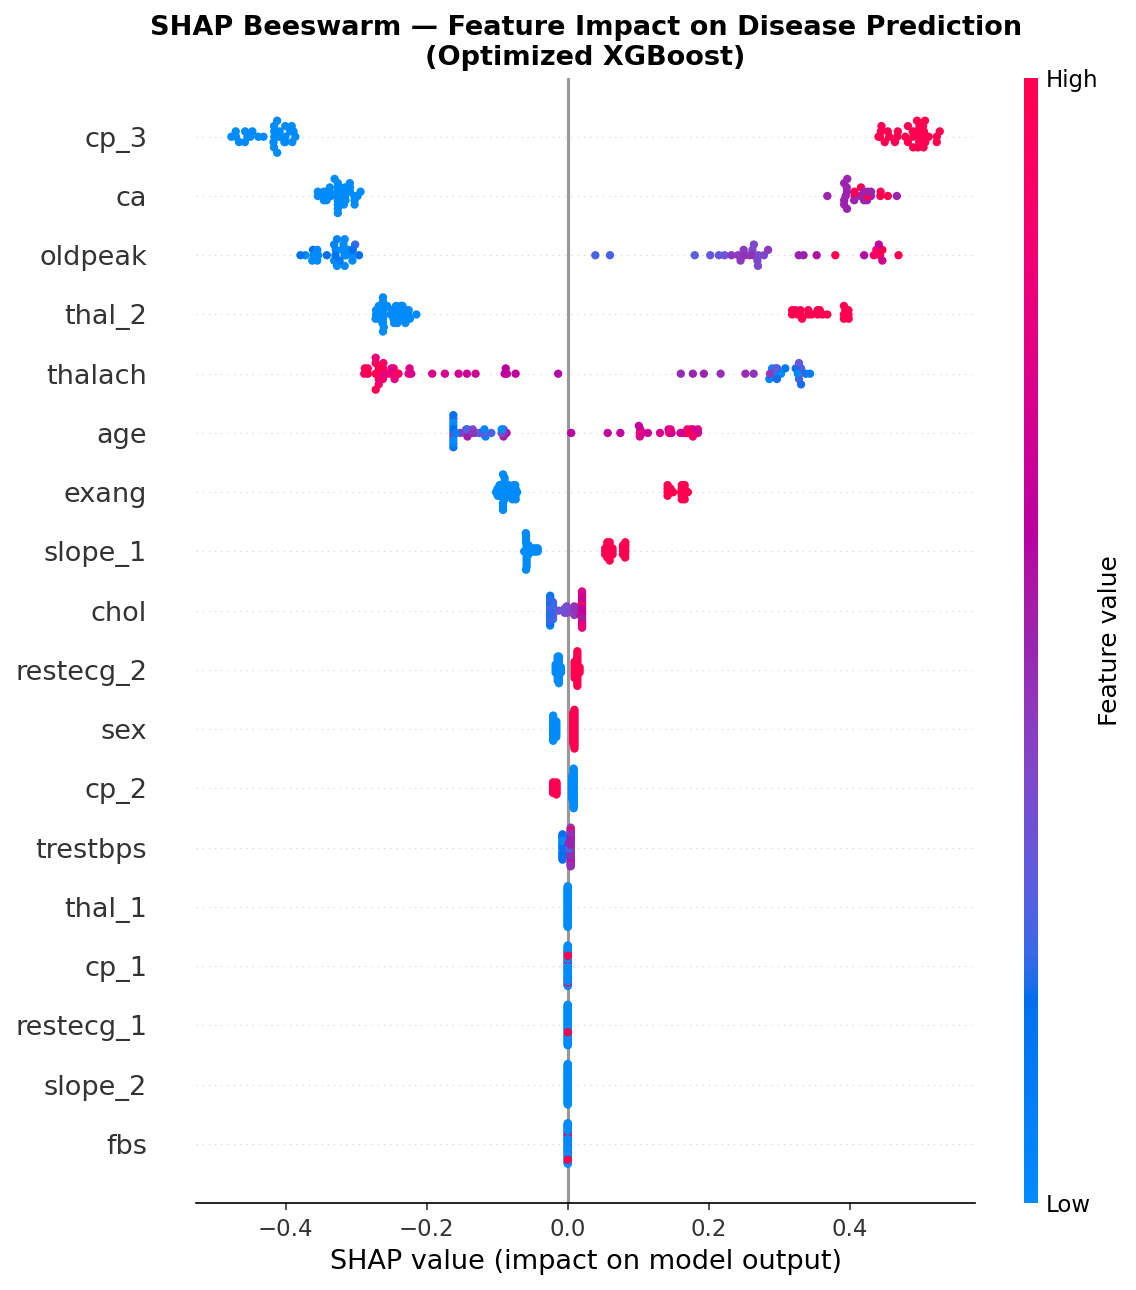

       ✓ SHAP beeswarm plot saved → shap_beeswarm.png


In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# SECTION 7 ▸ Explainability — SHAP Values + XGBoost Feature Importance
# ──────────────────────────────────────────────────────────────────────────────
print("\n[7/7]  Computing SHAP values for the optimised model …")

# ── SHAP TreeExplainer is native to tree-based models (no approximation) ─────
explainer = shap.TreeExplainer(optimized_model)
shap_values = explainer.shap_values(X_test_proc)     # shape: (n_samples, n_features)

X_test_df = pd.DataFrame(X_test_proc, columns=FEATURE_NAMES)

# ── 7a. SHAP Beeswarm (Summary) Plot ────────────────────────────────────────
# Each dot = one patient. Horizontal position = SHAP value (impact on output).
# Colour = feature value (red = high, blue = low).
# Tells us NOT just *which* features matter, but *how* they drive predictions.
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_df,
    plot_type = "dot",
    show      = False,
    max_display = len(FEATURE_NAMES),
)
plt.title("SHAP Beeswarm — Feature Impact on Disease Prediction\n(Optimized XGBoost)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", bbox_inches="tight")
plt.show()
print("       ✓ SHAP beeswarm plot saved → shap_beeswarm.png")

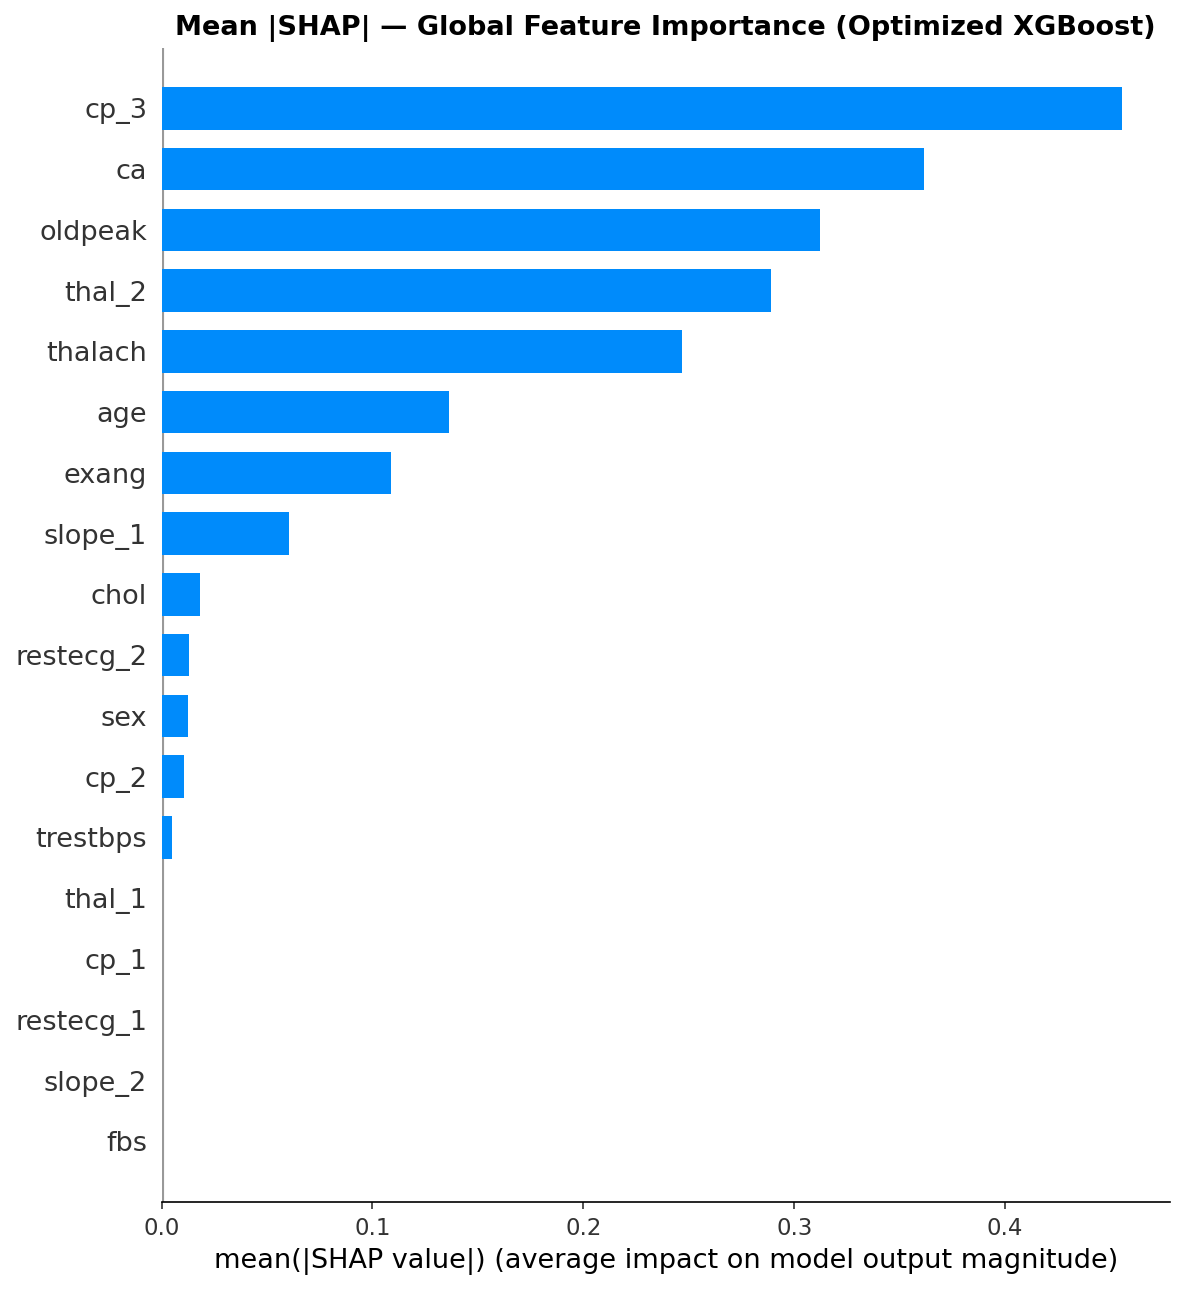

       ✓ SHAP bar plot saved → shap_bar.png


In [17]:
# ── 7b. SHAP Bar Plot (Mean |SHAP| = Global Importance) ─────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_df,
    plot_type   = "bar",
    show        = False,
    max_display = len(FEATURE_NAMES),
)
plt.title("Mean |SHAP| — Global Feature Importance (Optimized XGBoost)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar.png", bbox_inches="tight")
plt.show()
print("       ✓ SHAP bar plot saved → shap_bar.png")

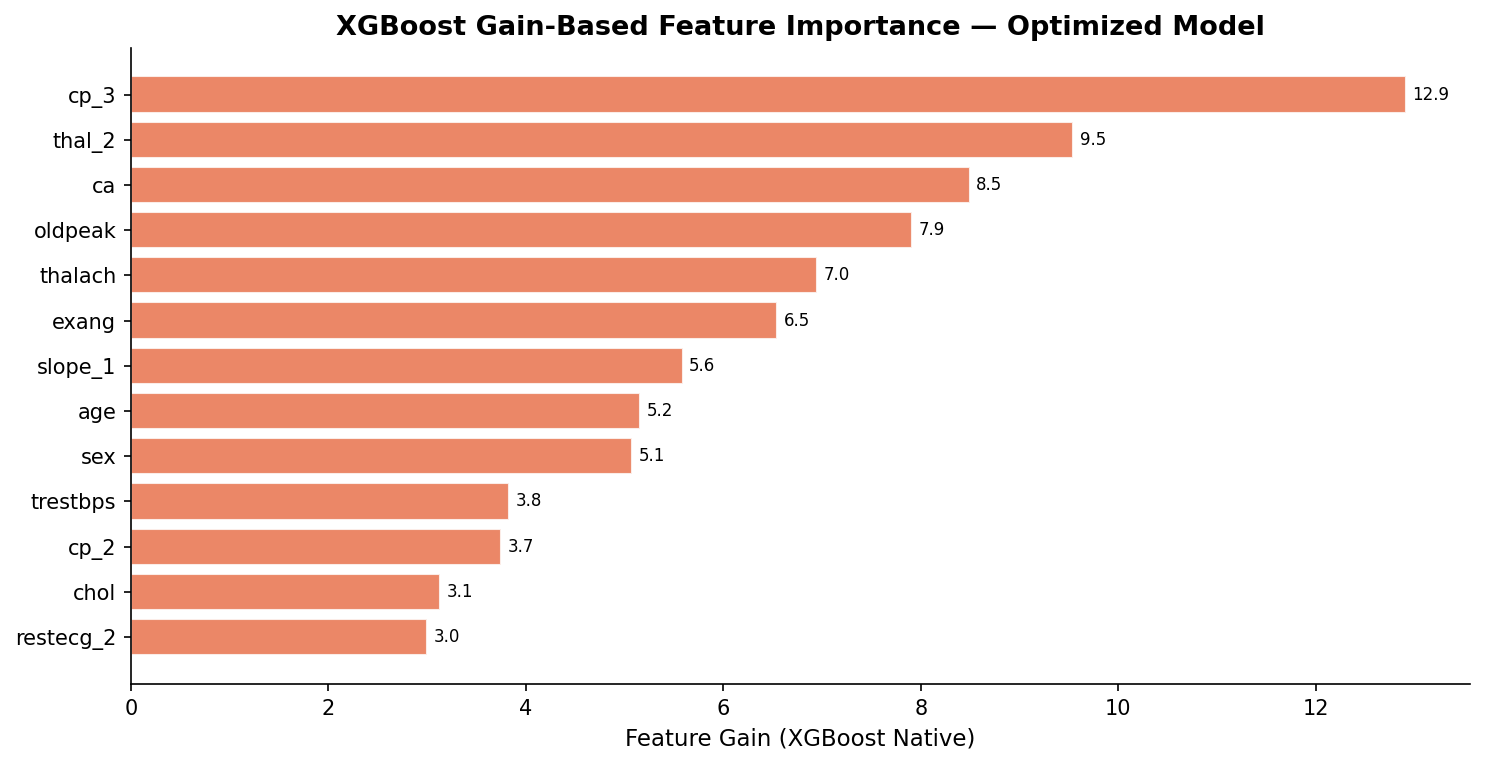

       ✓ Gain-based importance plot saved → feature_importance_gain.png


In [16]:
# ── 7c. XGBoost Native Gain-Based Feature Importance ────────────────────────
# "Gain" = the average improvement in loss brought by a feature across all
# splits that use it — a complementary view to SHAP.
importance_dict = optimized_model.get_booster().get_score(importance_type="gain")
importance_df   = (
    pd.DataFrame.from_dict(importance_dict, orient="index", columns=["Gain"])
    .reset_index().rename(columns={"index": "Feature"})
    .sort_values("Gain", ascending=True)
)

# Map f0, f1 … back to readable names
feature_map = {f"f{i}": name for i, name in enumerate(FEATURE_NAMES)}
importance_df["Feature"] = importance_df["Feature"].map(feature_map).fillna(importance_df["Feature"])

fig, ax = plt.subplots(figsize=(10, max(5, len(importance_df) * 0.4)))
bars = ax.barh(importance_df["Feature"], importance_df["Gain"],
               color=PALETTE["optimized"], edgecolor="white", alpha=0.85)
ax.set_xlabel("Feature Gain (XGBoost Native)", fontsize=11)
ax.set_title("XGBoost Gain-Based Feature Importance — Optimized Model",
             fontsize=13, fontweight="bold")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)
plt.tight_layout()
plt.savefig("feature_importance_gain.png", bbox_inches="tight")
plt.show()
print("       ✓ Gain-based importance plot saved → feature_importance_gain.png")

In [18]:

# ──────────────────────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  PIPELINE COMPLETE — FINAL RESULTS SUMMARY")
print("=" * 70)
print(results_df.to_string())
print("\n  Saved artefacts:")
print("    • confusion_matrices.png")
print("    • roc_curves.png")
print("    • shap_beeswarm.png")
print("    • shap_bar.png")
print("    • feature_importance_gain.png")
print("\n  Key Clinical Insight: Review 'Recall*' — a low recall means the")
print("  model is missing actual heart disease patients (false negatives),")
print("  which is the most dangerous error type in medical screening.")
print("=" * 70)



  PIPELINE COMPLETE — FINAL RESULTS SUMMARY
                   Accuracy  Recall*  Precision  F1-Score  AUC-ROC
Model                                                             
XGBoost Baseline     0.8833   0.8571     0.8889    0.8727   0.9431
XGBoost Optimized    0.8167   0.7143     0.8696    0.7843   0.9208

  Saved artefacts:
    • confusion_matrices.png
    • roc_curves.png
    • shap_beeswarm.png
    • shap_bar.png
    • feature_importance_gain.png

  Key Clinical Insight: Review 'Recall*' — a low recall means the
  model is missing actual heart disease patients (false negatives),
  which is the most dangerous error type in medical screening.
